In [1]:
# Step 1: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# Step 2: Create Synthetic Classification Dataset

X, y = make_classification(
    n_samples=300,          # Total data points
    n_features=2,           # Total input features
    n_informative=2,        # Useful features
    n_redundant=0,          # No redundant features
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (300, 2)
Target Shape: (300,)


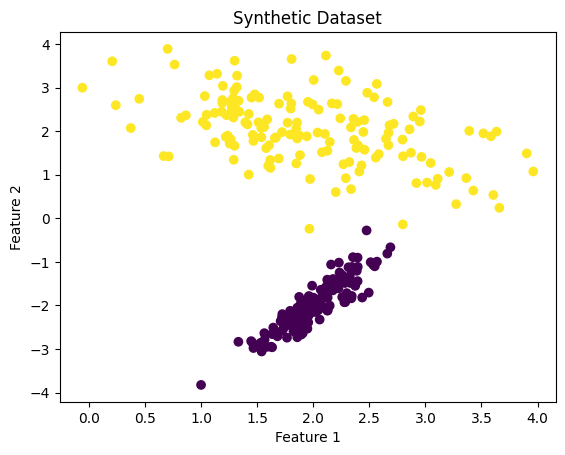

In [3]:
# Step 3: Plot Dataset

plt.scatter(X[:,0], X[:,1], c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Dataset")

plt.show()

In [4]:
# Step 4: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (240, 2)
Testing Shape: (60, 2)


In [5]:
# Step 5: Create Decision Tree Classifier

model = DecisionTreeClassifier(
    criterion='gini',   # Splitting method
    max_depth=3,        # Maximum depth of tree
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
# Step 6: Predict Test Data

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[0 1 1 0 1 1 1 1 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 1 0 1
 0 1 0 0 1 1 0 1 0 0 1 0 0 1 1 1 0 1 1 0 1 1 0]


In [7]:
# Step 7: Performance Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9833333333333333

Confusion Matrix:
[[28  1]
 [ 0 31]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.97      1.00      0.98        31

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



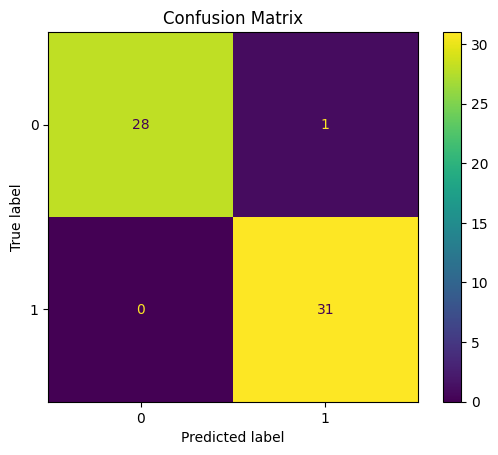

In [8]:
# Step 8: Visualize Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

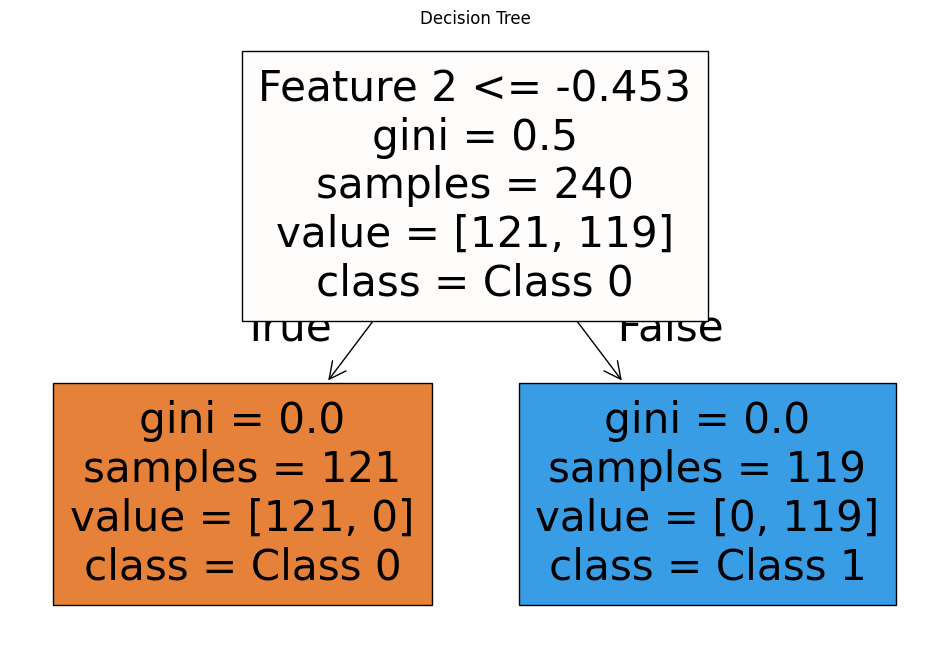

In [9]:
# Step 9: Plot Decision Tree

plt.figure(figsize=(12,8))

plot_tree(
    model,
    filled=True,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"]
)

plt.title("Decision Tree")

plt.show()

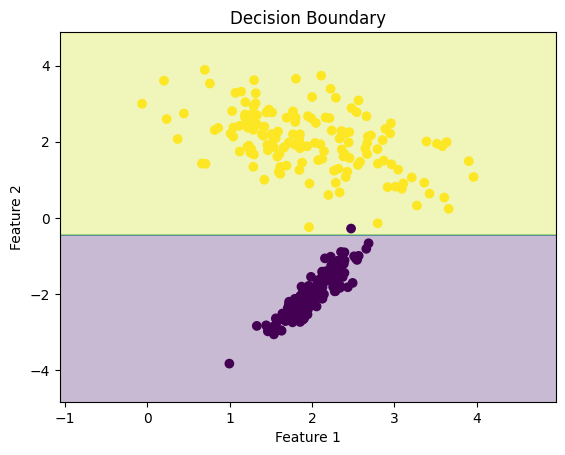

In [10]:
# Step 10: Plot Decision Boundary

def plot_decision_boundary(X, y, model):

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(X[:,0], X[:,1], c=y)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")

    plt.show()


plot_decision_boundary(X, y, model)

In [11]:
# Step 11: Predict New Custom Data

new_data = [[1.5, 2.0]]

prediction = model.predict(new_data)

print("Prediction for New Data:", prediction)

Prediction for New Data: [1]
